# Ranking articles by relevance

**Goal:** Create model to rank text according to importance to me.

**Use Case:** The text are summaries of articles I receive via a TLDR newsletter (tldr.tech). I want the articles to be ranked according to importance to me. To do this I hand-rated 1'114 summaries from 1-5 (5 being most important).
I read the TLDR newsletter daily and most of it is not for me.

**Implementation:**
1. **Propagation** - rating additional labels with k-NN over `all-MiniLM-L6-v2` embeddings
2. **Harness** - building the evaluation
3. **Module 1** - simple statistical model with TF-IDF vectorization and Ridge regression
4. **Module 2** - a feed-forward neural net on the `all-MiniLM-L6-v2` embeddings
5. **Hand labels only** - the same neural net without propagated labels
6. **Results** - comparing measurements

---

## Setup

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Randomness

SEED = 42
np.random.seed(SEED)

# Plotting

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

plt.rcParams.update({
    "figure.figsize":  (9, 4.5),
    "figure.dpi":      110,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":       10,
})



---

## Sample articles

In [2]:
items   = pd.read_csv("data/items.csv")
ratings = pd.read_csv("data/ratings.csv")

examples = items.merge(ratings, on="item_id")

for r in [1, 5]:
    row = examples[examples["rating"] == r].iloc[0]
    print(f"Rating {r}: {row['headline']}")
    print(row["summary"])
    print()

Rating 1: CONTINUOUS BATCHING
This post explains how continuous batching works. Continuous batching maximizes throughput by processing multiple conversations in parallel. Optimizing attention and KV caching enables faster and more scalable LLM serving under heavy user load.

Rating 5: ENTIRE ECONOMY
If xAI's model can successfully compete in League of Legends, that means that it would be able to read and understand any computer interface without needing a specialized API. The model will also need to be able to reason and produce a robust and complex plan. Such a model would be a game-changer for AI capabilities and the global economy.



---

## Propagation of hand labled ratings

1'114 of 2'215 articles carry a number I hand labeled. The other 1'101 get one copied from their nearest hand-rated neighbours in `all-MiniLM-L6-v2` embedding.

### The data

| File | What it holds |
|---|---|
| `data/items.csv` | 2'215 articles - headline, summary, section, category, date |
| `data/ratings.csv` | my 1'114 hand labeled ratings |
| `data/splits.csv` | the train / val / test assignment |

The split was was already created before the hand labeling.


In [3]:
ITEMS_CSV = "data/items.csv"
RATINGS_CSV = "data/ratings.csv"
SPLITS_CSV = "data/splits.csv"

items = pd.read_csv(ITEMS_CSV)
ratings = pd.read_csv(RATINGS_CSV)
splits = pd.read_csv(SPLITS_CSV)

print("items ", items.shape)
print("ratings ", ratings.shape)
print("splits ", splits.shape)
print()

counts = (splits.merge(ratings[["item_id", "rating"]], on="item_id", how="left")
                .groupby("split")["rating"]
                .agg(articles="size", hand_labelled="count")
                .reindex(["train", "val", "test"]))

print(counts.to_string())


items  (2215, 14)
ratings  (1114, 5)
splits  (2215, 3)

       articles  hand_labelled
split                         
train      1327            657
val         444            226
test        444            231


In [4]:
# My ratings:
print(items[["date", "headline", "section", "read_time"]].head(3).to_string())
print()
print(ratings.head(3).to_string())
print()
print("my ratings, 1-5:")
print(ratings["rating"].value_counts().reindex(range(1, 6)).to_string())

         date                                          headline                          section       read_time
0  2025-11-27                                          TO EARTH  Science & Futuristic Technology   6 MINUTE READ
1  2025-11-27  THE UNTOLD STORY OF CHARLIE MUNGER'S FINAL YEARS                    Miscellaneous  14 MINUTE READ
2  2025-11-27            FIRST MAKE IT FAST, THEN MAKE IT SMART                      Quick Links   4 MINUTE READ

        item_id  rating             rated_at   mode  round
0  ee04cee0b34e       2  2026-08-26T16:32:14  blind      1
1  a0534e798bd0       2  2026-08-26T16:32:25  blind      1
2  a1759eebfffc       3  2026-08-26T16:32:41  blind      1

my ratings, 1-5:
rating
1    189
2    303
3    334
4    217
5     71


### Embedding of articles

MiniLM turns each headline + summary into 384 dimension vectors.
Similar to transfer learning an existing model is used to create the article embeddings.

The embeddings are saved in the embeddings.npy file.

In [5]:
import os
from sentence_transformers import SentenceTransformer

EMBED_CACHE = "data/cache/embeddings.npy"

if os.path.exists(EMBED_CACHE):
    embeddings =np.load(EMBED_CACHE)
else:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(
        items["text"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    os.makedirs(os.path.dirname(EMBED_CACHE), exist_ok=True)
    np.save(EMBED_CACHE, embeddings)

print("embeddings", embeddings.shape)
print("article 0 :", np.round(embeddings[0][:8], 3))

embeddings (2215, 384)
article 0 : [-0.025  0.057  0.09   0.085  0.019 -0.001  0.051 -0.056]


### Propagating labels with k nearest neighbours

For each unrated article:

1. cosine similarity to every hand-rated article in that split
2. drop anything below `SIMILARITY_THRESHOLD` (0.50)
3. keep the best `K_NEIGHBOURS` (5)
4. label = similarity-weighted mean of their ratings
5. if nothing clears 0.50 -> no label, article left out


In [6]:
K_NEIGHBOURS         = 5
SIMILARITY_THRESHOLD = 0.50

# one row per article: its split, and its hand rating if it has one.
frame = (items[["item_id"]]
         .merge(splits[["item_id", "split"]],   on="item_id", how="left")
         .merge(ratings[["item_id", "rating"]], on="item_id", how="left"))

item_id_arr = frame["item_id"].to_numpy()
rating_arr  = frame["rating"].to_numpy()
is_rated    = frame["rating"].notna().to_numpy()

rows = []
for split_name in ["train", "val", "test"]:
    member = np.where(frame["split"] == split_name)[0]
    anchor = member[is_rated[member]]
    target = member[~is_rated[member]]

    for i in anchor:
        rows.append((item_id_arr[i], rating_arr[i], "hand", split_name))

    sims = embeddings[target] @ embeddings[anchor].T
    anchor_ratings = rating_arr[anchor]

    for r, i in enumerate(target):
        good = np.where(sims[r] >= SIMILARITY_THRESHOLD)[0]
        if len(good) == 0:
            continue   
        best = good[np.argsort(sims[r][good])[::-1][:K_NEIGHBOURS]]
        w = sims[r][best]
        rows.append((item_id_arr[i], float(w @ anchor_ratings[best] / w.sum()),
                     "propagated", split_name))

labels = pd.DataFrame(rows, columns=["item_id", "label", "source", "split"])
labels.to_csv("data/labels.csv", index=False)

print(labels.groupby(["split", "source"]).size().unstack(fill_value=0)
            .reindex(["train", "val", "test"]).to_string())
print()
print(f"{len(labels)} of {len(items)} articles have a label")

source  hand  propagated
split                   
train    657         670
val      226         218
test     231         213

2215 of 2215 articles have a label


In [7]:
# everything a model needs in one frame: text, metadata, label, split
data = labels.merge(items, on="item_id", how="left")

train, val, test = (data[data["split"] == s] for s in ["train", "val", "test"])

print(f"train {len(train)}   val {len(val)}   test {len(test)}")

train 1327   val 444   test 444


---

## The evaluation

### Primary: Spearman

Measures if the whole ranking is correct, not just the top 10.

In [9]:
from scipy.stats import spearmanr

def spearman(y_true, y_pred):
    return float(spearmanr(y_true, y_pred).statistic)

### Secondary: precision@10

Of the 10 articles ranked highest, how many did I rate 4 or 5.

In [8]:
PRECISION_AT        = 10
IMPORTANT_THRESHOLD = 4

def precision_at_k(y_true, y_pred, k=PRECISION_AT):
    """Of the k articles ranked highest, how many were labeled >= 4."""
    top = np.argsort(np.asarray(y_pred))[::-1][:k]
    return float(np.mean(np.asarray(y_true)[top] >= IMPORTANT_THRESHOLD))

print(f"test pool       {len(test)}")
print(f"floor (random)  {(test['label'] >= IMPORTANT_THRESHOLD).mean():.2f}")

test pool       444
floor (random)  0.28


### Evaluation function

One function to print both metrics with their context and append a row to
`results.csv`.

In [10]:
import os

RESULTS_CSV = "data/metrics/results.csv"
os.makedirs("data/metrics", exist_ok=True)

def evaluate(name, y_true, y_pred, pool):
    p     = precision_at_k(y_true, y_pred)
    rho   = spearman(y_true, y_pred)
    floor = (np.asarray(y_true) >= IMPORTANT_THRESHOLD).mean()

    print(f"{name:26s} p@{PRECISION_AT} {p:.2f} (floor {floor:.2f})   "
          f"spearman {rho:+.3f}   n={len(y_true)}  {pool}")

    pd.DataFrame([{"model": name, "pool": pool, "n": len(y_true),
                   "precision_at_k": p, "spearman": rho}]).to_csv(
        RESULTS_CSV, mode="a", header=not os.path.exists(RESULTS_CSV), index=False)
    return p, rho

---

## Module 1: TF-IDF vectorization + Ridge regression

### TF-IDF

TF-IDF is vectorizing text based on how often a word appears in an article, compared to how often that word appears across all articles.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(min_df=3, max_df=0.5, ngram_range=(1, 2),
                      stop_words="english", sublinear_tf=True)

Xtr = vec.fit_transform(train["text"])   # FIT here, on train only
Xva = vec.transform(val["text"])         # transform the validation set and test set
Xte = vec.transform(test["text"])

print("vocabulary  ", len(vec.vocabulary_))
print("train matrix", Xtr.shape)

vocabulary   3308
train matrix (1327, 3308)


### Ridge Regression

Fit a ridge regression model with a grid of alpha values.

In [12]:
from sklearn.linear_model import Ridge

RIDGE_ALPHA_GRID = [0.01, 0.1, 1, 10, 100, 1000]

scored = []
for alpha in RIDGE_ALPHA_GRID:
    model = Ridge(alpha=alpha).fit(Xtr, train["label"])
    rho = spearman(val["label"], model.predict(Xva))
    scored.append((rho, alpha, model))
    print(f"  alpha {alpha:>7}  spearman {rho:+.3f}")

_, best_alpha, ridge = max(scored, key=lambda t: t[0])

print(f"best alpha: {best_alpha}")
evaluate(f"ridge (alpha={best_alpha})", val["label"], ridge.predict(Xva),
         "val (hand+propagated)")
evaluate(f"ridge (alpha={best_alpha})", test["label"], ridge.predict(Xte),
         "test (hand+propagated)")

  alpha    0.01  spearman +0.394
  alpha     0.1  spearman +0.441
  alpha       1  spearman +0.542
  alpha      10  spearman +0.559
  alpha     100  spearman +0.542
  alpha    1000  spearman +0.540
best alpha: 10
ridge (alpha=10)           p@10 0.60 (floor 0.23)   spearman +0.559   n=444  val (hand+propagated)
ridge (alpha=10)           p@10 0.50 (floor 0.28)   spearman +0.480   n=444  test (hand+propagated)


(0.5, 0.480187498671903)

---

## Module 2: Feedforward neural network on the embeddings

A feedforward neural network over the 384 dimensions of the embeddings, using regularization techniques - dropout, L2, early stopping.

In [13]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import keras
from keras import layers

keras.utils.set_random_seed(SEED)

HIDDEN        = [128, 64]
DROPOUT       = 0.3
L2            = 0.001
LEARNING_RATE = 0.001
BATCH_SIZE    = 32
MAX_EPOCHS    = 50
PATIENCE      = 10

def build_nn(hidden=HIDDEN, dropout=DROPOUT, l2=L2, lr=LEARNING_RATE, input_dim=embeddings.shape[1]):
    model = keras.Sequential([keras.Input(shape=(input_dim,))])
    for units in hidden:
        model.add(layers.Dense(units, activation="relu",
                               kernel_regularizer=keras.regularizers.l2(l2)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    return model

nn = build_nn()
nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,601 (225.00 KB)

 Trainable params: 57,601 (225.00 KB)

 Non-trainable params: 0 (0.00 B)

### Training

Fit on the training set, with early stopping watching the validation loss.

In [14]:
# `data` is in label order, not items order, so map item_id -> embedding row
emb_row = pd.Series(range(len(items)), index=items["item_id"])

Etr = embeddings[emb_row[train["item_id"]].to_numpy()]
Eva = embeddings[emb_row[val["item_id"]].to_numpy()]
Ete = embeddings[emb_row[test["item_id"]].to_numpy()]

history = nn.fit(
    Etr, train["label"],
    validation_data=(Eva, val["label"]),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE,
                                             restore_best_weights=True)],
)

print(f"stopped after {len(history.history['loss'])} of {MAX_EPOCHS} epochs")

best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"best epoch {best_epoch}   val loss {min(history.history['val_loss']):.3f}")

stopped after 28 of 50 epochs
best epoch 18   val loss 0.901


### The loss curves

Training and validation loss together. If validation loss never turns upward, early stopping is
doing nothing - investigate before believing any result.

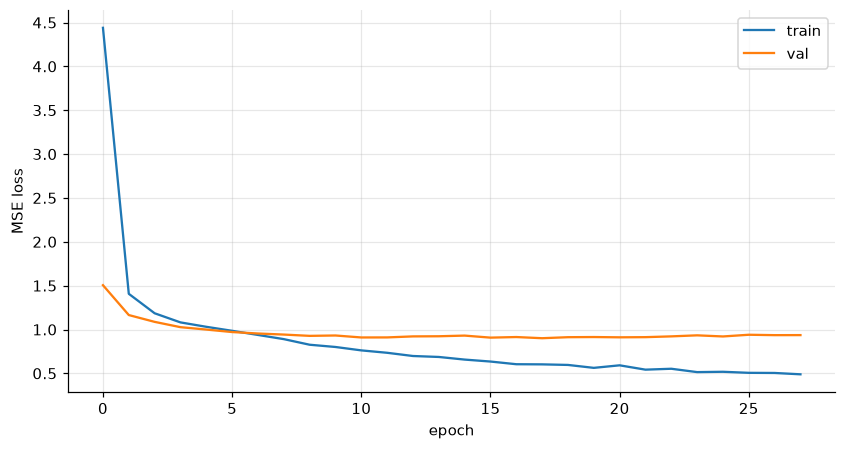

nn (hand-picked)           p@10 0.80 (floor 0.23)   spearman +0.592   n=444  val (hand+propagated)


(0.8, 0.5916185749377031)

In [15]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.show()

baseline_pred = nn.predict(Eva, verbose=0).ravel()
evaluate("nn (hand-picked)", val["label"], baseline_pred, "val (hand+propagated)")

---

## Hand-labelled data only

The same network with the same settings, but trained, validated and evaluated only on articles I
rated myself. No propagated labels anywhere.

In [16]:
hand = data[data["source"] == "hand"]
train_h, val_h, test_h = (hand[hand["split"] == s] for s in ["train", "val", "test"])

Etr_h = embeddings[emb_row[train_h["item_id"]].to_numpy()]
Eva_h = embeddings[emb_row[val_h["item_id"]].to_numpy()]
Ete_h = embeddings[emb_row[test_h["item_id"]].to_numpy()]

print(f"train {len(train_h)}   val {len(val_h)}   test {len(test_h)}")

keras.utils.set_random_seed(SEED)
nn_h = build_nn()

history_h = nn_h.fit(
    Etr_h, train_h["label"],
    validation_data=(Eva_h, val_h["label"]),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE,
                                             restore_best_weights=True)],
)

best_epoch = int(np.argmin(history_h.history["val_loss"])) + 1
print(f"best epoch {best_epoch}   val loss {min(history_h.history['val_loss']):.3f}")

train 657   val 226   test 231
best epoch 14   val loss 1.097


### Comparison

Both networks scored on the same hand-labelled articles, so the numbers are directly comparable.

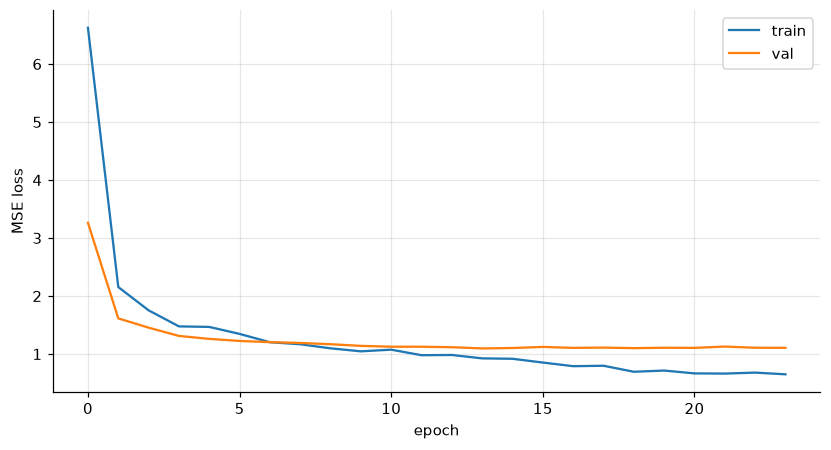

nn (hand+propagated)       p@10 0.80 (floor 0.23)   spearman +0.543   n=226  val (hand only)
nn (hand only)             p@10 0.70 (floor 0.23)   spearman +0.571   n=226  val (hand only)
nn (hand+propagated)       p@10 0.90 (floor 0.31)   spearman +0.515   n=231  test (hand only)
nn (hand only)             p@10 0.90 (floor 0.31)   spearman +0.542   n=231  test (hand only)


In [17]:
plt.plot(history_h.history["loss"], label="train")
plt.plot(history_h.history["val_loss"], label="val")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.legend()
plt.show()

for split_name, E, y in [("val", Eva_h, val_h["label"]), ("test", Ete_h, test_h["label"])]:
    evaluate("nn (hand+propagated)", y, nn.predict(E, verbose=0).ravel(), f"{split_name} (hand only)")
    evaluate("nn (hand only)",       y, nn_h.predict(E, verbose=0).ravel(), f"{split_name} (hand only)")

### Qwen3-Embedding

The same network on hand-labelled data only, but with `Qwen3-Embedding-0.6B` (1024 dimensions) instead
of MiniLM (384). The embedding model stays frozen; only the network is trained.

In [18]:
QWEN_CACHE = "data/cache/embeddings_qwen3.npy"

if os.path.exists(QWEN_CACHE):
    emb_qwen = np.load(QWEN_CACHE)
else:
    qwen = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
    emb_qwen = qwen.encode(items["text"].tolist(), batch_size=16, show_progress_bar=True,
                           normalize_embeddings=True).astype(np.float32)
    np.save(QWEN_CACHE, emb_qwen)

Etr_q = emb_qwen[emb_row[train_h["item_id"]].to_numpy()]
Eva_q = emb_qwen[emb_row[val_h["item_id"]].to_numpy()]
Ete_q = emb_qwen[emb_row[test_h["item_id"]].to_numpy()]

keras.utils.set_random_seed(SEED)
nn_q = build_nn(input_dim=emb_qwen.shape[1])
nn_q.fit(Etr_q, train_h["label"],
         validation_data=(Eva_q, val_h["label"]),
         epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, verbose=0,
         callbacks=[keras.callbacks.EarlyStopping(patience=PATIENCE,
                                                  restore_best_weights=True)])

for split_name, E, y in [("val", Eva_q, val_h["label"]), ("test", Ete_q, test_h["label"])]:
    evaluate("nn qwen3 (hand only)", y, nn_q.predict(E, verbose=0).ravel(), f"{split_name} (hand only)")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Batches:   0%|          | 0/139 [00:00<?, ?it/s]

nn qwen3 (hand only)       p@10 0.90 (floor 0.23)   spearman +0.633   n=226  val (hand only)
nn qwen3 (hand only)       p@10 0.90 (floor 0.31)   spearman +0.576   n=231  test (hand only)


---

## Results

All models scored on the same 231 hand-labelled test articles.

In [19]:
y = test_h["label"]

rows = []
for name, pred in [
    ("ridge (hand+propagated)", ridge.predict(vec.transform(test_h["text"]))),
    ("nn (hand+propagated)",    nn.predict(Ete_h, verbose=0).ravel()),
    ("nn (hand only)",          nn_h.predict(Ete_h, verbose=0).ravel()),
    ("nn qwen3 (hand only)",    nn_q.predict(Ete_q, verbose=0).ravel()),
]:
    rows.append({"model": name, "spearman": spearman(y, pred), "p@10": precision_at_k(y, pred)})

print(pd.DataFrame(rows).round(3).to_string(index=False))

                  model  spearman  p@10
ridge (hand+propagated)     0.458   0.7
   nn (hand+propagated)     0.515   0.9
         nn (hand only)     0.542   0.9
   nn qwen3 (hand only)     0.576   0.9


### Conclusion

- Propagation with k-NN did not help. The network trained on the hand-labelled articles alone ranks better than the same network with the propagated labels added.
- The neural network is slightly better than Ridge.
- Bigger embedding model in terms of parameter and output dimensions improves the result.
- A small network is enough. Testing with more layers and nodes did not improve the results.

---

## Example: ranking 10 random articles

10 random hand-labelled test articles, in the order the hand-only network ranks them, next to my
own rank.

In [20]:
sample = test_h.sample(10, random_state=SEED).copy()

sample["nn_score"] = nn_h.predict(embeddings[emb_row[sample["item_id"]].to_numpy()], verbose=0).ravel()
sample["nn_rank"]  = sample["nn_score"].rank(ascending=False).astype(int)
sample["my_rank"]  = sample["label"].rank(ascending=False, method="min").astype(int)

for _, r in sample.sort_values("nn_score", ascending=False).iterrows():
    first_words = " ".join(r["summary"].split()[:15])
    print(f"NN #{r['nn_rank']:<2}  my #{r['my_rank']:<2}  (rated {r['label']:.0f})  {r['headline']}")
    print(f"               {first_words} ...")
    print()

NN #1   my #3   (rated 3)  Why MistralAI Grows Faster Than OpenAI/Anthropic
               Mistral achieved a 20x growth in its ARR over the past year. It is expected ...

NN #2   my #3   (rated 3)  DYNAMIC LARGE CONCEPT MODELS
               DLCM replaces token-level computation with a hierarchical model that compresses inputs into variable-length concepts for ...

NN #3   my #3   (rated 3)  QWEN-DOC FOR LONG-CONTEXT DOCUMENTS
               Qwen-Doc is an open-source initiative for Document AI, offering models and tools to improve long-context ...

NN #4   my #3   (rated 3)  PERPLEXITY APIS POWER ANDROID OEM AI FEATURES
               Perplexity is supplying its AI APIs to a major Android device maker to enhance on-device ...

NN #5   my #1   (rated 4)  APEX-ACCOUNTING: AI PRODUCTIVITY BENCHMARK FOR ACCOUNTING
               APEX-Accounting, created by Ramp and Mercor, tests AI models' ability to complete accounting tasks across ...

NN #6   my #3   (rated 3)  STRIPE WILL REPORTEDLY 